<a href="https://colab.research.google.com/github/suriyaktc/DAsample2/blob/main/DASAMPLE3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Size    | Avg Binary Search Probes   | Avg Interpolation Search Probes
------------------------------------------------------------------------------
10000           | 12.27                      | 3.76                          
50000           | 14.70                      | 3.65                          
100000          | 15.69                      | 3.80                          


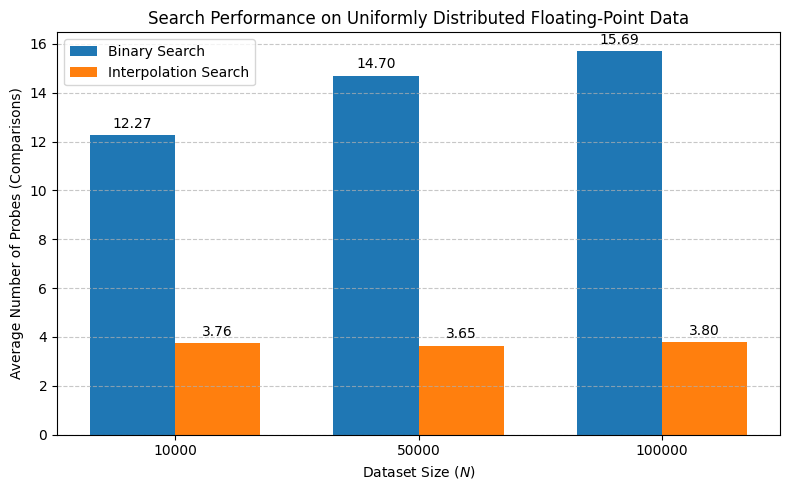

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

def binary_search_float(arr, target):
    """
    Standard Binary Search modified for floating-point array.
    """
    low = 0
    high = len(arr) - 1
    probes = 0

    while low <= high:
        probes += 1
        mid = (low + high) // 2

        if arr[mid] == target:
            return mid, probes
        elif arr[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    return -1, probes


def interpolation_search_float(arr, target):
    """
    Interpolation Search modified for floating-point array.
    """
    low = 0
    high = len(arr) - 1
    probes = 0

    while low <= high and arr[low] <= target <= arr[high]:
        probes += 1

        # Avoid division by zero if all remaining bounding elements are identical
        if arr[high] == arr[low]:
            if arr[low] == target:
                return low, probes
            break

        # Interpolation formula calculation using float values
        # Index 'pos' is derived via linear interpolation and then truncated to an integer
        pos = low + int(((high - low) / (arr[high] - arr[low])) * (target - arr[low]))

        # Clamp guards to prevent precision or rounding errors from overflowing array bounds
        if pos < low:
            pos = low
        elif pos > high:
            pos = high

        if arr[pos] == target:
            return pos, probes
        elif arr[pos] < target:
            low = pos + 1
        else:
            high = pos - 1

    return -1, probes


if __name__ == "__main__":
    # Dataset sizes to evaluate
    sizes = [10000, 50000, 100000]
    trials = 500

    avg_bs_probes = []
    avg_is_probes = []

    print(f"{'Dataset Size':<15} | {'Avg Binary Search Probes':<26} | {'Avg Interpolation Search Probes':<30}")
    print("-" * 78)

    for size in sizes:
        bs_total = 0
        is_total = 0

        # 1. Generate a uniformly distributed sorted floating-point array between 0.0 and 1000.0
        arr = np.sort(np.random.uniform(0.0, 1000.0, size))

        for _ in range(trials):
            # 2. Select a target element directly from the array to guarantee its existence
            target = random.choice(arr)

            # 3. Search and record probes
            _, bs_p = binary_search_float(arr, target)
            _, is_p = interpolation_search_float(arr, target)

            bs_total += bs_p
            is_total += is_p

        avg_bs = bs_total / trials
        avg_is = is_total / trials

        avg_bs_probes.append(avg_bs)
        avg_is_probes.append(avg_is)

        print(f"{size:<15} | {avg_bs:<26.2f} | {avg_is:<30.2f}")

    # --- Data Visualization ---
    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(sizes))
    width = 0.35

    rects1 = ax.bar(x - width/2, avg_bs_probes, width, label='Binary Search', color='#1f77b4')
    rects2 = ax.bar(x + width/2, avg_is_probes, width, label='Interpolation Search', color='#ff7f0e')

    ax.set_xlabel('Dataset Size ($N$)')
    ax.set_ylabel('Average Number of Probes (Comparisons)')
    ax.set_title('Search Performance on Uniformly Distributed Floating-Point Data')
    ax.set_xticks(x)
    ax.set_xticklabels([str(s) for s in sizes])
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Label the exact values on top of the bars
    ax.bar_label(rects1, padding=3, fmt='%.2f')
    ax.bar_label(rects2, padding=3, fmt='%.2f')

    plt.tight_layout()
    plt.savefig('search_comparison_chart.png')